In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as splat
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime
import os
from rubin_sim.data import get_baseline
from rubin_sim.splat.plots import bright_filter_colors

from rubin_scheduler.utils import (
    angular_separation,
    ddf_locations,hpid2_ra_dec)

from os.path import basename



In [2]:
# Read in the current baseline simulation
db_file = "baseline_v5.4.0b_10yrs.db"
data_source = basename(db_file).replace('.db', '')
con = sqlite3.connect(db_file)
df = pd.read_sql('select * from observations;', con)
con.close()
# Convert to a numpy array
visits_array = df.to_records(index=False)


In [3]:
fig_saver = splat.FigSaver(close_figs=False)

Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 g 20774 799 26


/Users/yoachim/anaconda3/envs/rubin_14/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 i 78302 799 98
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 r 50337 799 63
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 y 63121 799 79
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 z 73508 799 92
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 g 20774 799 26


/Users/yoachim/anaconda3/envs/rubin_14/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 i 78302 799 98
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 r 50337 799 63
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 y 78302 799 98
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 z 88689 799 111


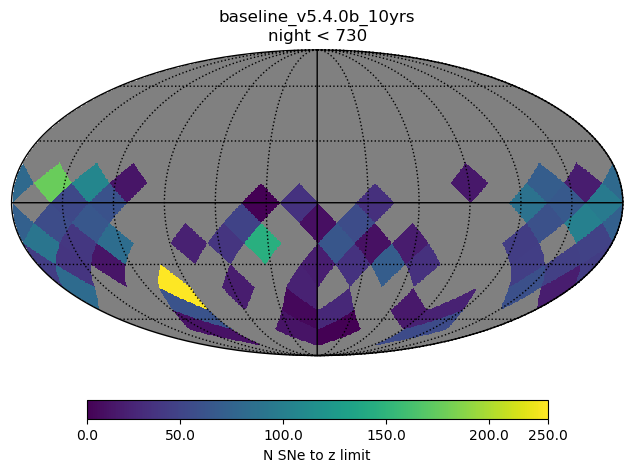

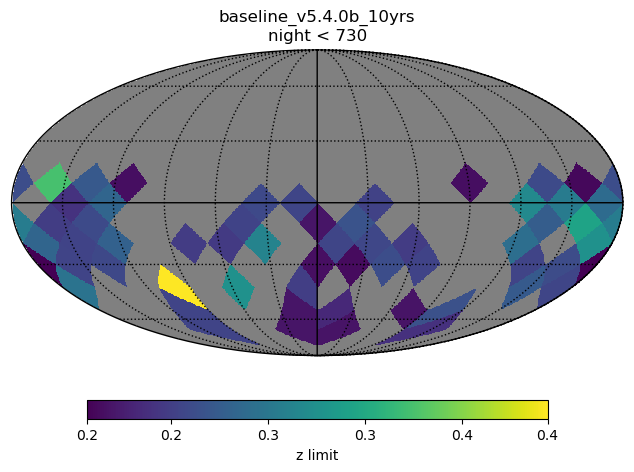

In [4]:
nside = 4
summary_stats = []

info = splat.empty_info()
info = {"data_source": data_source}
info["observations_subset"] = "night < 730"
sl = splat.Slicer(nside=nside)
metric = splat.SNNSNMetric(filter_col="band")
# Have now replaced with parallel call using processes=4
processes = 4

sub_data = visits_array[np.where(visits_array["night"] < 730)]

sn_array, info = splat.metric_parallel(sub_data, metric, sl, info=info, processes=processes)
pm = splat.PlotMoll(info=info)

# Need to split the info dict so 
# files don't clobber
metric_basename = info["name"]
fig = pm(sn_array["n_sn"], unit="N SNe to z limit")
info["name"] = metric_basename + " N SN"
fig_saver(fig, info=info)
fig = pm(sn_array["zlim"], unit="z limit")
info["name"] = metric_basename + " z lim"
fig_saver(fig, info=info)

summary_stats.append(splat.gen_summary_row(info, "sum N SNe", np.nansum(sn_array["n_sn"])))
summary_stats.append(splat.gen_summary_row(info, "mean z limit", np.nanmean(sn_array["zlim"])))
summary_stats.append(splat.gen_summary_row(info, "median z limit", np.nanmedian(sn_array["zlim"])))

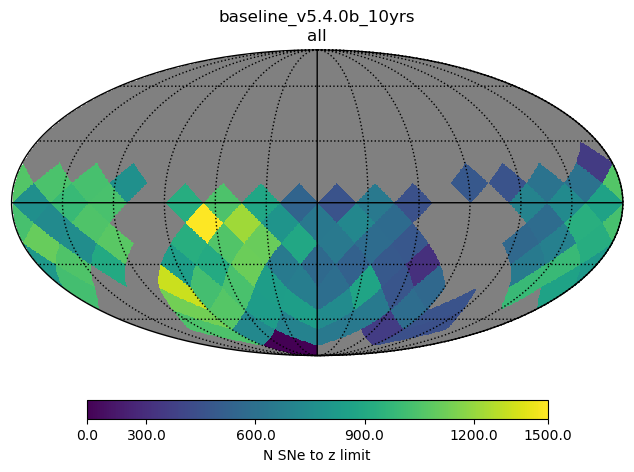

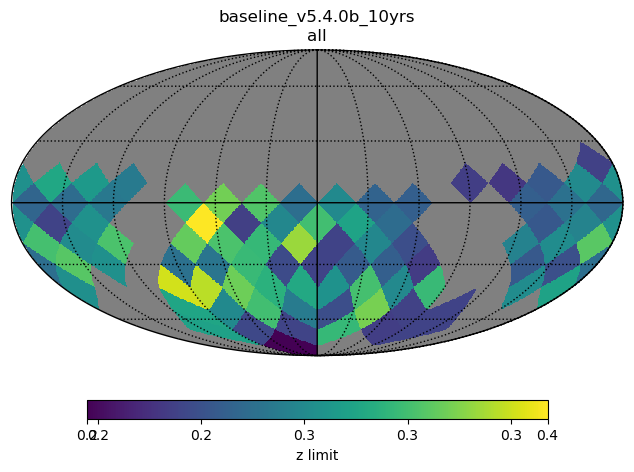

In [5]:

nside = 4

info = splat.empty_info()
info = {"data_source": data_source}
info["observations_subset"] = "all"
sl = splat.Slicer(nside=nside)
metric = splat.SNNSNMetric(filter_col="band")
# Have now replaced with parallel call using processes=4
processes = 4
sn_array, info = splat.metric_parallel(visits_array, metric, sl, info=info, processes=processes)
pm = splat.PlotMoll(info=info)

# Need to split the info dict so 
# files don't clobber
metric_basename = info["name"]
fig = pm(sn_array["n_sn"], unit="N SNe to z limit")
info["name"] = metric_basename + " N SN"
fig_saver(fig, info=info)
fig = pm(sn_array["zlim"], unit="z limit")
info["name"] = metric_basename + " z lim"
fig_saver(fig, info=info)

summary_stats.append(splat.gen_summary_row(info, "sum N SNe", np.nansum(sn_array["n_sn"])))
summary_stats.append(splat.gen_summary_row(info, "mean z limit", np.nanmean(sn_array["zlim"])))
summary_stats.append(splat.gen_summary_row(info, "median z limit", np.nanmedian(sn_array["zlim"])))

In [7]:
# Read in the current baseline simulation
db_file = "baseline_v5.3.7_10yrs.db"
data_source = basename(db_file).replace('.db', '')
con = sqlite3.connect(db_file)
df = pd.read_sql('select * from observations;', con)
con.close()
# Convert to a numpy array
visits_array = df.to_records(index=False)


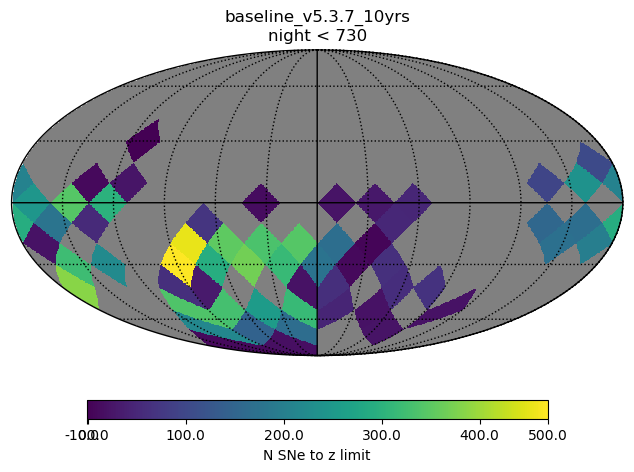

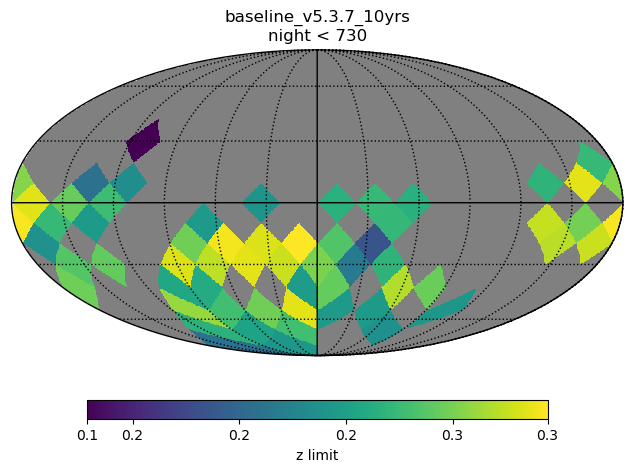

In [8]:
info = splat.empty_info()
info = {"data_source": data_source}
info["observations_subset"] = "night < 730"
sl = splat.Slicer(nside=nside)
metric = splat.SNNSNMetric(filter_col="band")
# Have now replaced with parallel call using processes=4
processes = 4

sub_data = visits_array[np.where(visits_array["night"] < 730)]

sn_array, info = splat.metric_parallel(sub_data, metric, sl, info=info, processes=processes)
pm = splat.PlotMoll(info=info)

# Need to split the info dict so 
# files don't clobber
metric_basename = info["name"]
fig = pm(sn_array["n_sn"], unit="N SNe to z limit")
info["name"] = metric_basename + " N SN"
fig_saver(fig, info=info)
fig = pm(sn_array["zlim"], unit="z limit")
info["name"] = metric_basename + " z lim"
fig_saver(fig, info=info)

summary_stats.append(splat.gen_summary_row(info, "sum N SNe", np.nansum(sn_array["n_sn"])))
summary_stats.append(splat.gen_summary_row(info, "mean z limit", np.nanmean(sn_array["zlim"])))
summary_stats.append(splat.gen_summary_row(info, "median z limit", np.nanmedian(sn_array["zlim"])))

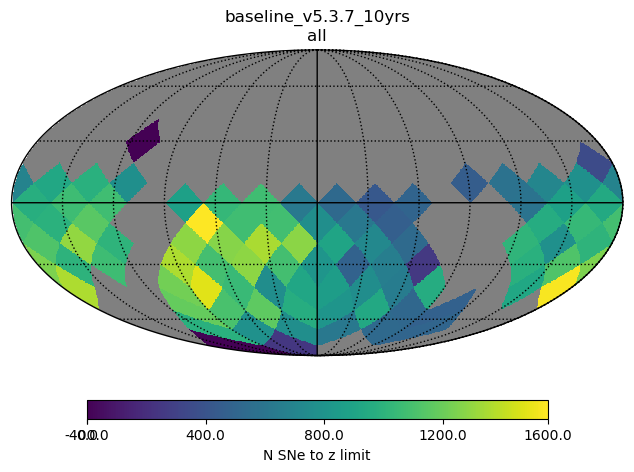

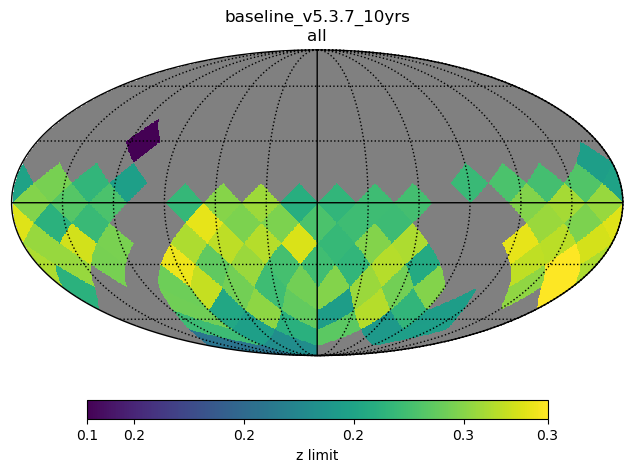

In [9]:
info = splat.empty_info()
info = {"data_source": data_source}
info["observations_subset"] = "all"
sl = splat.Slicer(nside=nside)
metric = splat.SNNSNMetric(filter_col="band")
# Have now replaced with parallel call using processes=4
processes = 4
sn_array, info = splat.metric_parallel(visits_array, metric, sl, info=info, processes=processes)
pm = splat.PlotMoll(info=info)

# Need to split the info dict so 
# files don't clobber
metric_basename = info["name"]
fig = pm(sn_array["n_sn"], unit="N SNe to z limit")
info["name"] = metric_basename + " N SN"
fig_saver(fig, info=info)
fig = pm(sn_array["zlim"], unit="z limit")
info["name"] = metric_basename + " z lim"
fig_saver(fig, info=info)

summary_stats.append(splat.gen_summary_row(info, "sum N SNe", np.nansum(sn_array["n_sn"])))
summary_stats.append(splat.gen_summary_row(info, "mean z limit", np.nanmean(sn_array["zlim"])))
summary_stats.append(splat.gen_summary_row(info, "median z limit", np.nanmedian(sn_array["zlim"])))

In [10]:
pd.DataFrame.from_dict(summary_stats)


,data_source,name,col,unit,times,observations_subset,population,nside,summary_name,value,table_name,caption,group,subgroup,plot_filename,data_filename
0,baseline_v5.4.0b_10yrs,SNNSNMetric z lim,,,,night < 730,,4,sum N SNe,3087.475057,,,,,,
1,baseline_v5.4.0b_10yrs,SNNSNMetric z lim,,,,night < 730,,4,mean z limit,0.251888,,,,,,
2,baseline_v5.4.0b_10yrs,SNNSNMetric z lim,,,,night < 730,,4,median z limit,0.244840,,,,,,
3,baseline_v5.4.0b_10yrs,SNNSNMetric z lim,,,,all,,4,sum N SNe,67643.062795,,,,,,
4,baseline_v5.4.0b_10yrs,SNNSNMetric z lim,,,,all,,4,mean z limit,0.274180,,,,,,
5,baseline_v5.4.0b_10yrs,SNNSNMetric z lim,,,,all,,4,median z limit,0.274408,,,,,,
6,baseline_v5.3.7_10yrs,SNNSNMetric z lim,,,,night < 730,,4,sum N SNe,9580.525833,,,,,,
7,baseline_v5.3.7_10yrs,SNNSNMetric z lim,,,,night < 730,,4,mean z limit,0.279502,,,,,,
8,baseline_v5.3.7_10yrs,SNNSNMetric z lim,,,,night < 730,,4,median z limit,0.279127,,,,,,
9,baseline_v5.3.7_10yrs,SNNSNMetric z lim,,,,all,,4,sum N SNe,77909.699849,,,,,,
